## Assignment 3: $k$ Nearest Neighbor


**Q1.**
1. What is the difference between regression and classification?
2. What is a confusion table? What does it help us understand about a model's performance?
3. What does the SSE quantify about a particular model?
4. What are overfitting and underfitting? 
5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance?
6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the features.
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Ashley Tibebe

**Date:** 09/29/2026

In [436]:
# Your Phase 1 solution to the problem goes here.

Q1:
1) The difference between regression and classification is that regression is used to predict a numeric outcome (numeric variables), while classification is used to predict a category (categorical variables). For example, regression could be used to predict the average income of a country, while classification could be used to predict whether the country is classified as developed or developing.
2) A confusion table is a way to evaluate predictions by counting predictions by actual and predicted class. This allows us to see the correct and incorrect predictions made by a model and thus evaluate its performance by exposing if it is able to properly make and classify predictions.
3) SSE quantifies the total amount of error or variation that exists between the predicted values made by the model and the actual observed data. It does this by squaring the differences between observed and predicted values and summing them.
4) Overfitting is associated with a very small k, which means the model learns from and includes too much noise and outliers from the data, while underfitting is associated with a very large k, meaning the model is too simple and fails to highlight differences between observations.
5) Splitting the data into training and testing sets improves model performance because it allows us to evaluate how well the model can predict observations that were not in the training set (new observations that it was not learning based off of). Additionally, choosing k value based on the training data will allow us to select the optimal k and tests its accuracy with the testing data set and ensure that the optimal k leads to the best predictions and avoids under or overfitting the data.
6) Reporting a class label as a prediction has strength in its ability to provide a label to categorical variables, while its weakness is that it does not associate a probability to that observation falling under that label. On the other hand, reporting a class label as a probability distribution has its strength in that it presents data with its associated probability, while its weakness is that it is not as applicable to categorical data and might only be appropriate for numerical data.

In [437]:
#Q2: 
import pandas as pd
land_mines = pd.read_csv('land_mines.csv')

In [438]:
print(land_mines.head())
print(land_mines.dtypes)
print(land_mines['mine_type'].value_counts().sort_index())



    voltage    height  soil  mine_type
0  0.338157  0.000000   0.0          1
1  0.320241  0.181818   0.0          1
2  0.287009  0.272727   0.0          1
3  0.256284  0.454545   0.0          1
4  0.262840  0.545455   0.0          1
voltage      float64
height       float64
soil         float64
mine_type      int64
dtype: object
mine_type
1    71
2    70
3    66
4    66
5    65
Name: count, dtype: int64


I decided to explore the data first by taking a quick look at the way the data is organized by printing the first fives rows of the data and a list of the variables present. Next, I decided to take a closer look at the mine_type variable and understand how many of each type of mine is present in the data to give myself an understanding of which type if data is the most common. 

In [439]:
pip install pandas


[notice] A new release of pip is available: 23.1.2 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [440]:
pip install matplotlib


[notice] A new release of pip is available: 23.1.2 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [441]:
import matplotlib.pyplot as plt

In [442]:
pip install numpy


[notice] A new release of pip is available: 23.1.2 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [443]:
import numpy as np

In [444]:
import pandas as pd

Text(0, 0.5, 'Frequency')

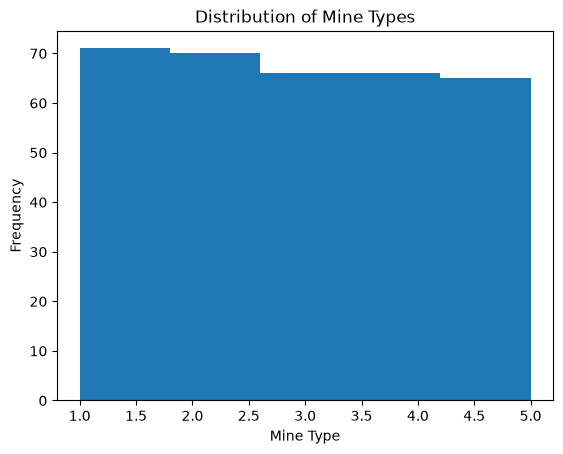

In [445]:
land_mines["mine_type"].hist(bins=5, grid=False)
plt.title("Distribution of Mine Types")
plt.xlabel("Mine Type")
plt.ylabel("Frequency")


From this, I can see that the number of mine types in each category (1-5) are not starkly different from each other. 

In [446]:
pip install scikit-learn


[notice] A new release of pip is available: 23.1.2 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [447]:
from sklearn.preprocessing import MinMaxScaler

In [448]:
from sklearn.model_selection import train_test_split

In [449]:
X_raw = land_mines[["voltage", "height", "soil"]]
y = land_mines["mine_type"]
(
    X_train_raw,
    X_test_raw,
    y_train,
    y_test,
) = train_test_split(
    X_raw, y, test_size=0.50, random_state=42
)

eval_scaler = MinMaxScaler()
eval_X_train_scaled = eval_scaler.fit_transform(X_train_raw)
eval_X_test_scaled = eval_scaler.transform(X_test_raw)

In [450]:
from sklearn.neighbors import KNeighborsClassifier

In [451]:
eval_ks = np.arange(1, 51)
eval_valid_sse = []
eval_train_sse = []
for eval_k in eval_ks:
    eval_candidate = KNeighborsClassifier(n_neighbors=int(eval_k))
    eval_candidate.fit(eval_X_train_scaled, y_train)
    eval_valid_hat = eval_candidate.predict(eval_X_test_scaled)
    eval_train_hat = eval_candidate.predict(eval_X_train_scaled)
    eval_valid_sse.append(np.sum(
        (y_test.to_numpy() - eval_valid_hat) ** 2
    ))
    eval_train_sse.append(np.sum(
        (y_train.to_numpy() - eval_train_hat) ** 2
    ))
    eval_k_star = int(eval_ks[np.argmin(eval_valid_sse)])
print(eval_k_star)


2


This code identinfies a k of 2 being the optimal k. You select k by finding the value of k that corresponds to the lowest SSE (Sum of Squared Errors). In the code above, "eval_k_star = int(eval_ks[np.argmin(eval_valid_sse)])" selects the value with the minimum SSE value, which becomes the optimal k value. 

In [452]:
#Confusion table
from sklearn.metrics import confusion_matrix

In [453]:
final_model = KNeighborsClassifier(n_neighbors=eval_k_star)
final_model.fit(eval_X_train_scaled, y_train)
final_predictions = final_model.predict(eval_X_test_scaled)
cm = confusion_matrix(y_test, final_predictions)
print(cm)

[[19  0 15  2  1]
 [ 0 26  3  4  0]
 [ 8  2 17  2  3]
 [10  4 11  8  3]
 [ 6  3 13  6  3]]


Although this is the correct confusion table, it is difficult to understand without proper labels. I decided to make another conusion table (below).

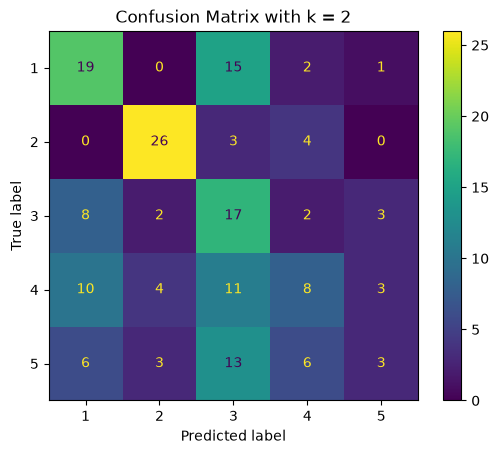

In [454]:
disp = ConfusionMatrixDisplay.from_estimator(
    final_model, 
    eval_X_test_scaled, 
    y_test,
)
plt.title("Confusion Matrix with k = 2")
plt.show()

This confusion table shows that the model is moderately inaccurate because for most of the mines (1-5), they are identified correctly most commonly and the predicted and true label correspond. However, when the amount of times the mine was predicted incorrectly is added together such as in mine type 3, 4 and 5, we can see that these mines are predicted incorrectly most of the time. On the other hand, the prediction for the mine type 2 is the most accurate with 26 of them being identified correctly and only 9 mines being predicted incorrectly.

Because of the mistakes this model makes, I would advise someone to use this model only to predict if a mine is mine type 2. The mines that are type 2 are largely predicted correctly while all the others are not. Therefore, I would advise that this model is only used when predicting the likelihood of a mine being type 2. However, in general I would advise that this model is not relyed on soley for predictions. 

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [To be provided]
- **AI tool and model used:** [To be provided]

### *Prompts used

1. [Paste prompt]
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. ...
2. ...

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [455]:
# Your Phase 2 solution to the problem goes here.


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]